# Build a Question/Answering system over SQL data

* we'll go over the basic ways to create a Q&A system over tabular data in databases.
* We will cover implementations using both chains and agents.
* These systems will allow us to ask a question about the data in a database and get back a natural language answer.
* The main difference between the two is that our agent can query the database in a loop as many times as it needs to answer the question.

# Architecture
At a high-level, the steps of these systems are:

* Convert question to SQL query: Model converts user input to a SQL query.
* Execute SQL query: Execute the query.
* Answer the question: Model responds to user input using the query resu

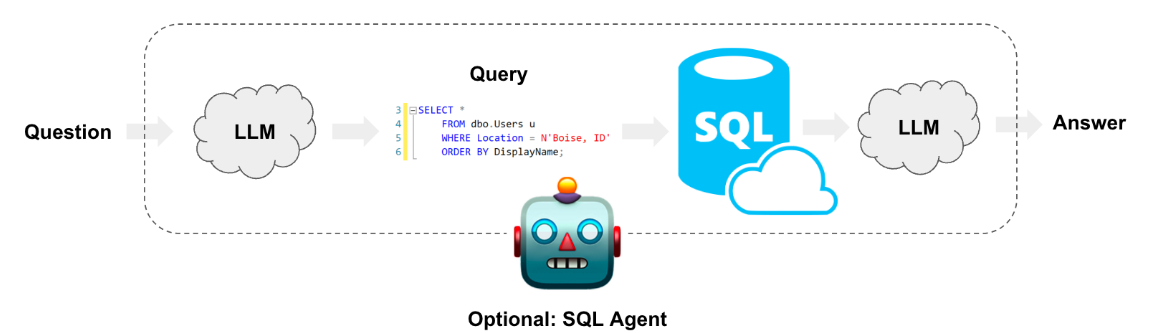

In [6]:
%%capture --no-stderr
%pip install --upgrade --quiet langchain-community langchainhub langgraph


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")
print(db.dialect)


sqlite


In [2]:
db.get_table_info()

'\nCREATE TABLE "Album" (\n\t"AlbumId" INTEGER NOT NULL, \n\t"Title" NVARCHAR(160) NOT NULL, \n\t"ArtistId" INTEGER NOT NULL, \n\tPRIMARY KEY ("AlbumId"), \n\tFOREIGN KEY("ArtistId") REFERENCES "Artist" ("ArtistId")\n)\n\n/*\n3 rows from Album table:\nAlbumId\tTitle\tArtistId\n1\tFor Those About To Rock We Salute You\t1\n2\tBalls to the Wall\t2\n3\tRestless and Wild\t2\n*/\n\n\nCREATE TABLE "Artist" (\n\t"ArtistId" INTEGER NOT NULL, \n\t"Name" NVARCHAR(120), \n\tPRIMARY KEY ("ArtistId")\n)\n\n/*\n3 rows from Artist table:\nArtistId\tName\n1\tAC/DC\n2\tAccept\n3\tAerosmith\n*/\n\n\nCREATE TABLE "Customer" (\n\t"CustomerId" INTEGER NOT NULL, \n\t"FirstName" NVARCHAR(40) NOT NULL, \n\t"LastName" NVARCHAR(20) NOT NULL, \n\t"Company" NVARCHAR(80), \n\t"Address" NVARCHAR(70), \n\t"City" NVARCHAR(40), \n\t"State" NVARCHAR(40), \n\t"Country" NVARCHAR(40), \n\t"PostalCode" NVARCHAR(10), \n\t"Phone" NVARCHAR(24), \n\t"Fax" NVARCHAR(24), \n\t"Email" NVARCHAR(60) NOT NULL, \n\t"SupportRepId" INTEG

In [5]:
print(db.get_usable_table_names())


['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


In [7]:
db.run("SELECT * FROM Artist LIMIT 10;")

"[(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains'), (6, 'Antônio Carlos Jobim'), (7, 'Apocalyptica'), (8, 'Audioslave'), (9, 'BackBeat'), (10, 'Billy Cobham')]"

In [9]:
db.run("Select count(*) from Artist")

'[(275,)]'

In [11]:
type(db.run("SELECT * FROM Artist LIMIT 10;"))

str

In [13]:
db.dialect

'sqlite'

# Chains
- Chains are **compositions of predictable steps**.
- In LangGraph, we can represent a chain via simple sequence of nodes. Let's create a sequence of steps that, given a question, does the following:

- converts the question into a SQL query;
- executes the query;
- uses the result to answer the original question.
- There are scenarios not supported by this arrangement. For example, this system will execute a SQL query for any user input-- even "hello". Importantly, as we'll see below, some questions require more than one query to answer. We will address these scenarios in the Agents section.

### Chains in LangChain
- Chains in LangChain are sequences of components that work together to process data, pass it through a series of steps, and eventually generate a final result. Chains can be used to combine different logic in a structured way, allowing you to compose more complex behaviors with individual components like LLMs (Large Language Models), data retrieval, or custom functions.

-Technical Explanation:
A chain is a set of actions, or steps, where the output of one step is used as the input for the next. In LangChain, a chain could involve:

- **LLM chains**: These involve multiple interactions with language models to generate text based on a series of prompts or other inputs.
- **Tool chains**: These involve interacting with multiple APIs, databases, or functions in a sequential manner to gather data or perform tasks.
- **Custom chains**: You can define your custom logic using LangChain’s building blocks, like prompts, models, and tools, that execute in a specific order.

# Application state
The LangGraph state of our application controls what data is input to the application, transferred between steps, and output by the application. It is typically a TypedDict, but can also be a Pydantic BaseModel.

For this application, we can just keep track of the input question, generated query, query result, and generated answer

In [19]:
from typing_extensions import TypedDict

class State(TypedDict):
    question: str  # The user's input question
    query: str     # The generated query (e.g., for a search engine or database)
    result: str    # The retrieved result from the query execution
    answer: str    # The final AI-generated answer based on the query result


# Convert question to SQL query

The first step is to take the user **input and convert it to a SQL query**. 

In [23]:
# !pip install -qU langchain-mistralai

In [25]:
# !pip install langchain_openai

In [27]:
# import getpass
import os

# if not os.environ.get("TOGETHER_API_KEY"):
#   os.environ["TOGETHER_API_KEY"] = getpass.getpass("Enter API key for Together AI: ")

from langchain_openai import ChatOpenAI

In [33]:
# !pip show openai
# !pip install --upgrade openai



In [29]:


llm = ChatOpenAI(
    base_url="https://api.together.xyz/v1",
    api_key=os.environ["TOGETHERAI_API_KEY"],
    model="meta-llama/Llama-3.3-70B-Instruct-Turbo-Free",
)

In [43]:
from langchain import hub


query_prompt_template = hub.pull("langchain-ai/sql-query-system-prompt")

len(query_prompt_template.messages) == 1
query_prompt_template.messages[0].pretty_print()

C:\Users\esvit\anaconda3\Lib\site-packages\langsmith\client.py:280: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


================================ System Message ================================

Given an input question, create a syntactically correct {dialect} query to run to help find the answer. Unless the user specifies in his question a specific number of examples they wish to obtain, always limit your query to at most {top_k} results. You can order the results by a relevant column to return the most interesting examples in the database.

Never query for all the columns from a specific table, only ask for a the few relevant columns given the question.

Pay attention to use only the column names that you can see in the schema description. Be careful to not query for columns that do not exist. Also, pay attention to which column is in which table.

Only use the following tables:
{table_info}


In [45]:
# query_prompt_template

In [65]:
# !pip install --upgrade openai langchain


In [67]:
from typing_extensions import Annotated


class QueryOutput(TypedDict):
    """Generated SQL query."""

    query: Annotated[str, ..., "Syntactically valid SQL query."]


def write_query(state: State):
    """Generate SQL query to fetch information."""
    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "top_k": None,
            "table_info": db.get_table_info(),
            "input": state["question"],
        }
    )
    structured_llm = llm.with_structured_output(QueryOutput)
    result = structured_llm.invoke(prompt)
    return {"query": result['query']}

In [69]:
write_query({"question": "How many TOTAL  Employees are there  in employees?"})


BadRequestError: Error code: 400 - {'id': 'nuWaQ9m-3NKUce-9419ef12ff5191cd', 'error': {'message': 'invalid tools grammar: Model supports only tool_choice auto', 'type': 'invalid_request_error', 'param': 'tools', 'code': None}}

### Executing query

In [32]:
from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool


def execute_query(state: State):
    """Execute SQL query."""
    execute_query_tool = QuerySQLDatabaseTool(db=db)
    return {"result": execute_query_tool.invoke(state["query"])}

In [34]:
execute_query({"query": "SELECT COUNT(EmployeeId) AS EmployeeCount FROM Employee;"})

{'result': '[(8,)]'}

# Generate answers

In [36]:
def generate_answer(state: State):
    """Answer question using retrieved information as context."""
    prompt = (
        f"""Given the following user question, corresponding SQL query, 
        and SQL result, answer the user question.\n\n. """
        f'Question: {state["question"]}\n'
        f'SQL Query: {state["query"]}\n'
        f'SQL Result: {state["result"]}'
    )
    response = llm.invoke(prompt)
    return {"answer": response.content}

# Orchestrating with LangGraph

Finally, we compile our application into a single graph object. In this case, we are just connecting the ``three steps into a single sequence``.

In [40]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence(
    [write_query, execute_query, generate_answer]
)
graph_builder.add_edge(START, "write_query")
graph = graph_builder.compile()

### How Execution Works
- The user provides an input state (State).
- The execution starts at write_query.
- The output of write_query is passed to execute_query.
- The result of execute_query is given to generate_answer.
Finally, the graph produces the final state with the generated answer.

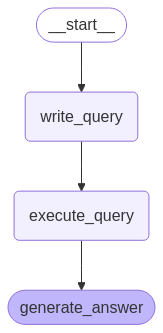

In [42]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [44]:
for step in graph.stream(
    {"question": "How many employees are there in total?"}, stream_mode="updates"
):
    print(step)

{'write_query': {'query': 'SELECT COUNT(*) FROM Employee'}}
{'execute_query': {'result': '[(8,)]'}}
{'generate_answer': {'answer': 'There are 8 employees in total.'}}


In [77]:
for step in graph.stream(
    {"question": "How many employees are there in total?"}
):
    print(step)

{'write_query': {'query': 'SELECT COUNT(EmployeeId) FROM Employee'}}
{'execute_query': {'result': '[(8,)]'}}
{'generate_answer': {'answer': 'There are 8 employees in total. Jai Hind!'}}


In [46]:
for step in graph.stream(
    {"question": "How manysongs from Aerosmith?"}, stream_mode="updates"
):
    print(step)

{'write_query': {'query': "SELECT COUNT(T1.TrackId) FROM Track AS T1 INNER JOIN Album AS T2 ON T1.AlbumId = T2.AlbumId INNER JOIN Artist AS T3 ON T2.ArtistId = T3.ArtistId WHERE T3.Name = 'Aerosmith'"}}
{'execute_query': {'result': '[(15,)]'}}
{'generate_answer': {'answer': 'There are 15 songs from Aerosmith.'}}


# 2. Conneducting RAG through MYSQL DataBase

### 2.1 bringing sql table from MYSQL

In [107]:
import mysql.connector
#connection with db
connection = mysql.connector.connect(
    host='localhost',
    user='root',
    password=password,
    database='employees'
)
cursor = connection.cursor(buffered=True)
# cursor.execute('SHOW TABLES')
# tables = cursor.fetchall()
# tables
#database
select_query = 'SELECT * FROM employees LIMIT 10'
cursor.execute(select_query)
# 
row = cursor.fetchall()


In [109]:
# cursor.execute('select * from titles')
# row=cursor.fetchall()
# row

### 2.2 RAG QnA

In [112]:

import os


#model instantiate 
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url="https://api.together.xyz/v1",
    api_key=os.environ["TOGETHERAI_API_KEY"],
    model="meta-llama/Llama-3.3-70B-Instruct-Turbo-Free",
)

### Procedure
- 1. convert english query into sql code
- 2. execute code to retreive data
- 3. generate answer from that data

### Converting query to code

In [116]:
# prompt = f'''follow the instructions strictly.
# only provide the SQL code for the question asked below.
# {question}
# never provide anything other than that.
# no english , no puncutaltuins.'''

In [118]:
question = 'How many employees are there whose salary is greater than 60000 in salaries table'
prompt = prompt.format({'question':question})
prompt

' given the result received (200686,) of the sql query.\nprovide the result to the user in max 20 words.\ninclude`` hello your result is`` before result\nalways say good bye in the end\n'

In [120]:
prompt = f'''follow the instructions strictly.
only provide the SQL code for the question asked below.
{question}
never provide anything other than that.
no english , no puncutaltuins.'''

In [122]:
query = llm.invoke(prompt)

query = query.content
query

'SELECT COUNT(*) FROM salaries WHERE salary > 60000'

### executing query

In [125]:
cursor.execute(query)
result=cursor.fetchall()
result = str(result[0]) #casting in string
result

'(200686,)'

In [93]:
type(result)

str

-  **the answer is retrived**

### Generate answer

In [127]:
prompt = f''' given the result received {result} of the sql query.
provide the result to the user in max 20 words.
include`` hello your result is`` before result
always say good bye in the end
'''
final = llm.invoke(prompt)


In [128]:
final.content

'Hello your result is 200686. Good bye.'